# Local Outlier Factor

In [1]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_moons, make_circles, make_blobs
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
X,y=make_blobs(
    n_samples=500,
    centers=3, ## henerally meaning 3 clusters
    n_features=2, ## This is better for visualization
    random_state=10,
    cluster_std=2.0
)
    

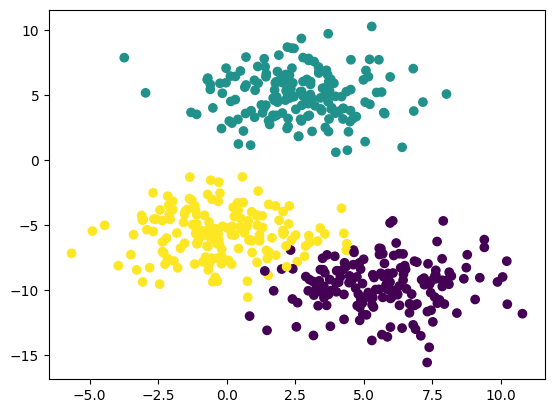

In [3]:
plt.scatter(X[:,0],X[:,1],c=y)

In [4]:
from sklearn.neighbors import LocalOutlierFactor

We wont be doing predictions on tests just training data X. This LOF is used to identify local outliers. We are not predicting values but predicting the likelihood that a data-point is an outlier

In [5]:
lof=LocalOutlierFactor(n_neighbors=5)
pred=lof.fit_predict(X)
pred

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1, -1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

The -1 are the outliers in the dataset. We can visualize this data to see the datapoints that are outliers.

In [6]:
## Lets pull out the index of the labels that are less than 0
import numpy as np
index = np.where(pred < 0)
index

(array([ 28,  66,  69,  75,  78,  85, 163, 239, 243, 282, 292, 306, 369,
        374, 400, 456, 457, 485, 497]),)

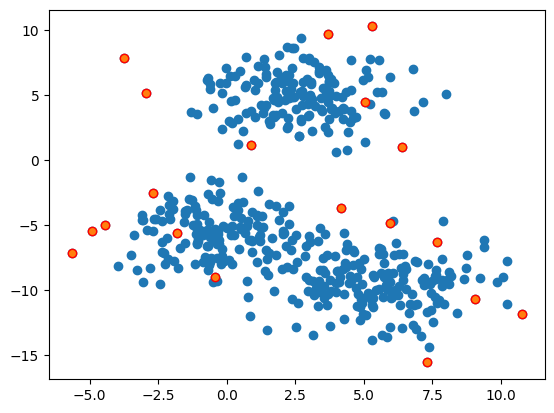

In [7]:
plt.scatter(X[:,0], X[:,1])
plt.scatter(X[index,0], X[index,1], edgecolors="r")

We can improve the outlier identification. We can observe that some outliers might have been misclassified. We will compare the predicted outputs with the negative_outlier_factor_

In [8]:
import pandas as pd

In [9]:
compare_df = pd.DataFrame({
    'Predicted values': pred,
    'Negative outlier factor': lof.negative_outlier_factor_
})

compare_df

,Predicted values,Negative outlier factor
0,1,-0.954830
1,1,-0.977751
2,1,-1.226425
3,1,-1.043040
4,1,-1.112894
...,...,...
495,1,-1.191457
496,1,-1.125930
497,-1,-1.734804
498,1,-0.936470


In [10]:
compare_df['Negative outlier factor'].max()

np.float64(-0.8813235168682102)

In [11]:
compare_df['Negative outlier factor'].min()

np.float64(-3.967665982103223)

In [12]:
np.percentile(lof.negative_outlier_factor_, [1, 5, 10, 25, 50])

array([-1.81112733, -1.41468664, -1.31278033, -1.12887741, -1.04262492])

Score
-3.97  |  <-- extreme outlier
-2.50  |
-2.00  |
-1.81  |  <-- 1st percentile
-1.41  |  <-- 5th percentile
-1.31  |  <-- 10th percentile
-1.13  |  <-- 25th percentile
-1.04  |  <-- median
-0.88  |  <-- most normal point

This percentile helps to us to identify the spread of the negative_outlier_factor_. It is observed that fewer number of data points have -1.811 and above. Let us set the threshold as -1.811

In [13]:
pd.Series(lof.negative_outlier_factor_).describe()

count    500.000000
mean      -1.103513
std        0.214772
min       -3.967666
25%       -1.128877
50%       -1.042625
75%       -0.999695
max       -0.881324
dtype: float64

In [14]:
threshold=-1.811

custom_pred = np.where(
    lof.negative_outlier_factor_ < threshold,
)

In [15]:
custom_pred

(array([ 28,  66,  78, 282, 292, 485]),)

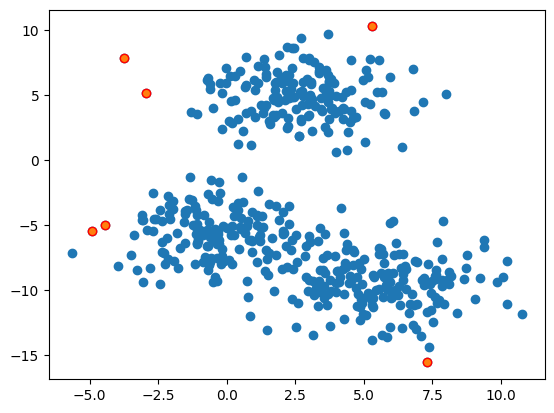

In [16]:
plt.scatter(X[:,0], X[:,1])
plt.scatter(X[custom_pred,0], X[custom_pred,1], edgecolors="r")

Lets ease out the threshold.

In [17]:
threshold=-1.5

custom_pred = np.where(
    lof.negative_outlier_factor_ < threshold,
)
custom_pred

(array([ 28,  66,  69,  75,  78,  85, 163, 239, 243, 282, 292, 306, 369,
        374, 400, 456, 457, 485, 497]),)

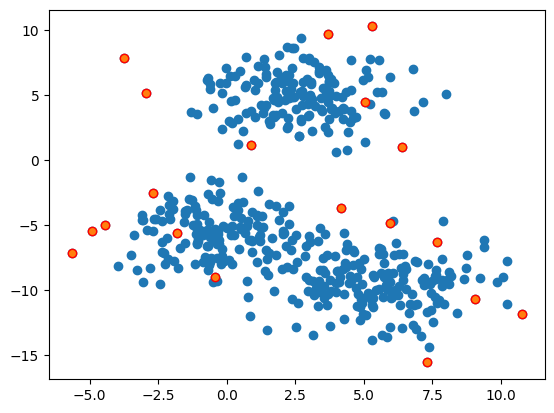

In [18]:
plt.scatter(X[:,0], X[:,1])
plt.scatter(X[custom_pred,0], X[custom_pred,1], edgecolors="r")

In [19]:
import sys

print(sys.executable)

c:\Users\pc\Downloads\python_machine_learning\venv\python.exe
